# ***A. PREPROCESSING DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("data_scraping_tiktok_pemerintahan kota batu.csv", delimiter=";")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               1647 non-null   object
 1   diggCount          1647 non-null   int64 
 2   replyCommentTotal  1647 non-null   int64 
 3   createTimeISO      1647 non-null   object
 4   uniqueId           1647 non-null   object
 5   videoWebUrl        1647 non-null   object
 6   uid                1647 non-null   object
 7   cid                1647 non-null   object
 8   avatarThumbnail    1647 non-null   object
dtypes: int64(2), object(7)
memory usage: 115.9+ KB


,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,videoWebUrl,uid,cid,avatarThumbnail
0,membangun sinergi dan kolaborasi ke depannya,0,0,03/06/2025 20:38,oktevabusokte,https://www.tiktok.com/@nurochmanheli/video/74...,"7,00957E+18","7,51172E+18",https://p19-common-sign-sg.tiktokcdn-us.com/to...
1,"Hallo pak, bikin program rumah murah ding, bua...",0,0,30/04/2025 23:01,njajanoofficial,https://www.tiktok.com/@nurochmanheli/video/74...,"6,96574E+18","7,49914E+18",https://p16-common-sign-sg.tiktokcdn-us.com/to...
2,"assalamualaikum wr WB pak, mohon atensinya unt...",1,0,29/04/2025 10:56,mas_yusuf94,https://www.tiktok.com/@nurochmanheli/video/74...,"1,41848E+17","7,49858E+18",https://p19-common-sign-va.tiktokcdn-us.com/to...
3,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,0,0,09/05/2025 09:32,rinyrizki30,https://www.tiktok.com/@nurochmanheli/video/74...,"6,87832E+18","7,50227E+18",https://p16-common-sign-va.tiktokcdn-us.com/to...
4,datang tidak dianggap kalo mau pulang cepet-ce...,167,9,16/07/2025 00:40,.hnaudio,https://www.tiktok.com/@ariefmemo7/video/75271...,"7,13267E+18","7,52736E+18",https://p16-common-sign-sg.tiktokcdn-us.com/to...


In [ ]:
# Konversi ke datetime dengan format Indonesia/Eropa (dd/mm/yyyy)
data['createTimeISO'] = pd.to_datetime(data['createTimeISO'], dayfirst=True)

# Pisahkan menjadi tanggal dan jam
data['tanggal'] = data['createTimeISO'].dt.date
data['jam'] = data['createTimeISO'].dt.time

In [ ]:
df = pd.DataFrame(data[['tanggal', 'jam', 'uniqueId', 'diggCount', 'text']])
df.head(5)

,tanggal,jam,uniqueId,diggCount,text
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua..."
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt..."
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...


In [ ]:
df = df.rename(columns={
    'tanggal': 'date',
    'jam': 'time',
    'uniqueId': 'username',
    'diggCount': 'diggCount',
    'text': 'text'
})

df.head()

,date,time,username,diggCount,text
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua..."
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt..."
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...


### **1. Hapus Data Duplikat**

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1647 non-null   object
 1   time       1647 non-null   object
 2   username   1647 non-null   object
 3   diggCount  1647 non-null   int64 
 4   text       1647 non-null   object
dtypes: int64(1), object(4)
memory usage: 64.5+ KB


In [ ]:
df.drop_duplicates(subset ="text", keep = 'first', inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1646
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1460 non-null   object
 1   time       1460 non-null   object
 2   username   1460 non-null   object
 3   diggCount  1460 non-null   int64 
 4   text       1460 non-null   object
dtypes: int64(1), object(4)
memory usage: 68.4+ KB


### **2. WordCloud Sebelum Preprocecessing**

---



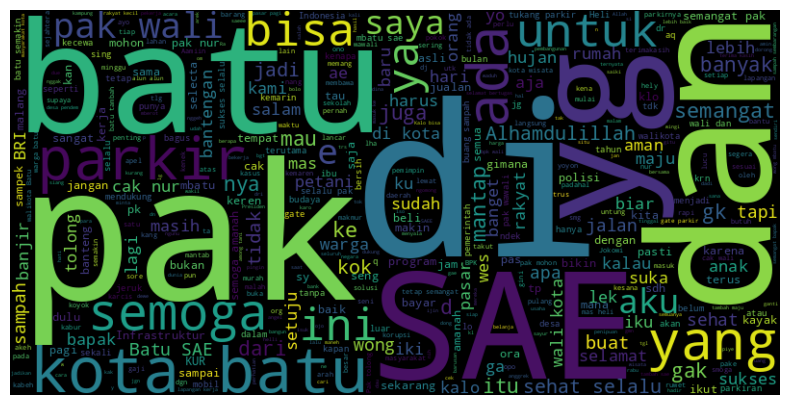

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# Mengisi nilai NaN dengan string kosong ('')
df['text'] = df['text'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

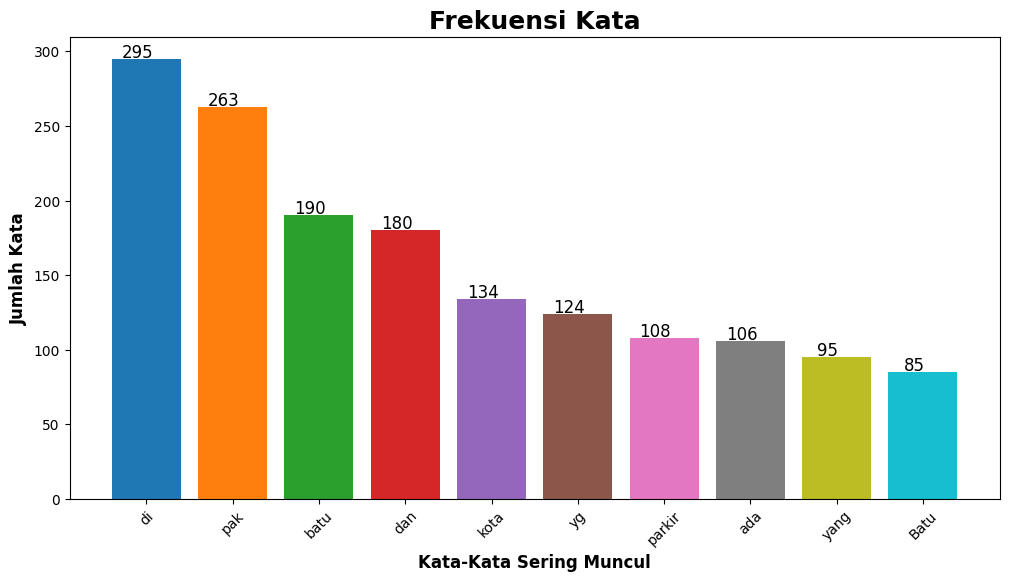

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

### **3. Cleaning**

---



In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] = df['text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

,date,time,username,diggCount,text,cleaning
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...
5,2025-07-23,09:56:00,whietapriyantto,0,"nanya warga batu saja,lbh setuju atau gak ada ...",nanya warga batu sajalbh setuju atau gak ada g...
6,2025-07-16,09:13:00,bennyheslax,25,gate parkir itu lebih tepatnya Untuk lahan par...,gate parkir itu lebih tepatnya Untuk lahan par...
7,2025-07-17,21:02:00,ir6732,3,pak wali di data ktp batu apa luar batu,pak wali di data ktp batu apa luar batu
8,2025-07-16,18:22:00,sugiarno87,6,parkir beli obat 3000 parkir 3000 .batu dikit ...,parkir beli obat parkir batu dikit dikit parkir
9,2025-07-16,13:35:00,sonia_ajhe,1,intinya saya minta satu y jalan raya jgn buat ...,intinya saya minta satu y jalan raya jgn buat ...


### **4. Case Folding**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,date,time,username,diggCount,text,cleaning,case_folding
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...


### **5. Normalisasi Kata**

---



In [ ]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['date','time','username','diggCount','text','cleaning','case_folding']])
data.head()

,date,time,username,diggCount,text,cleaning,case_folding
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...


In [ ]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['date','time','username','diggCount','text','cleaning','case_folding','normalisasi']])
df.head(5)

,date,time,username,diggCount,text,cleaning,case_folding,normalisasi
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...,halo pak bikin program rumah murah ding buat w...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalau mau pulang cepetce...


### **6. Tokenization**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,date,time,username,diggCount,text,cleaning,case_folding,normalisasi,tokenize
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,"[membangun, sinergi, dan, kolaborasi, ke, depa..."
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...,halo pak bikin program rumah murah ding buat w...,"[halo, pak, bikin, program, rumah, murah, ding..."
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,"[assalamualaikum, wr, wb, pak, mohon, atensiny..."
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,"[riny, rizkiriny, rizkibagaimana, dengan, pkl,..."
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalau mau pulang cepetce...,"[datang, tidak, dianggap, kalau, mau, pulang, ..."


### **7. StopWord Removal**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

,date,time,username,diggCount,text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,"[membangun, sinergi, dan, kolaborasi, ke, depa...","[membangun, sinergi, kolaborasi, depannya]"
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...,halo pak bikin program rumah murah ding buat w...,"[halo, pak, bikin, program, rumah, murah, ding...","[halo, bikin, program, rumah, murah, ding, war..."
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,"[assalamualaikum, wr, wb, pak, mohon, atensiny...","[assalamualaikum, wr, wb, mohon, atensinya, wi..."
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,"[riny, rizkiriny, rizkibagaimana, dengan, pkl,...","[riny, rizkiriny, rizkibagaimana, pkl, gusur, ..."
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalau mau pulang cepetce...,"[datang, tidak, dianggap, kalau, mau, pulang, ...","[dianggap, pulang, cepetcepet, uang, parkirnya]"


### **8. Steaming**

---



In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,date,time,username,diggCount,text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,"[membangun, sinergi, dan, kolaborasi, ke, depa...","[membangun, sinergi, kolaborasi, depannya]",bangun sinergi kolaborasi depan
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...,halo pak bikin program rumah murah ding buat w...,"[halo, pak, bikin, program, rumah, murah, ding...","[halo, bikin, program, rumah, murah, ding, war...",halo bikin program rumah murah ding warga kota...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,"[assalamualaikum, wr, wb, pak, mohon, atensiny...","[assalamualaikum, wr, wb, mohon, atensinya, wi...",assalamualaikum wr wb mohon atensi wilayah rw ...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,"[riny, rizkiriny, rizkibagaimana, dengan, pkl,...","[riny, rizkiriny, rizkibagaimana, pkl, gusur, ...",riny rizkiriny rizkibagaimana pkl gusur satpol...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalau mau pulang cepetce...,"[datang, tidak, dianggap, kalau, mau, pulang, ...","[dianggap, pulang, cepetcepet, uang, parkirnya]",anggap pulang cepetcepet uang parkir


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1646
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              1460 non-null   object
 1   time              1460 non-null   object
 2   username          1460 non-null   object
 3   diggCount         1460 non-null   int64 
 4   text              1460 non-null   object
 5   cleaning          1460 non-null   object
 6   case_folding      1460 non-null   object
 7   normalisasi       1460 non-null   object
 8   tokenize          1460 non-null   object
 9   stopword removal  1460 non-null   object
 10  steming_data      1460 non-null   object
dtypes: int64(1), object(10)
memory usage: 169.2+ KB


### **9. Hapus Nilai Kosong (Nan)**

---



In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1646
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              1460 non-null   object
 1   time              1460 non-null   object
 2   username          1460 non-null   object
 3   diggCount         1460 non-null   int64 
 4   text              1460 non-null   object
 5   cleaning          1460 non-null   object
 6   case_folding      1460 non-null   object
 7   normalisasi       1460 non-null   object
 8   tokenize          1460 non-null   object
 9   stopword removal  1460 non-null   object
 10  steming_data      1460 non-null   object
dtypes: int64(1), object(10)
memory usage: 169.2+ KB


Tambahan


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()


,text,clean_text
0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya
1,"Hallo pak, bikin program rumah murah ding, bua...",hallo pak bikin program rumah murah ding buat ...
2,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr wb pak mohon atensinya untu...
3,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,riny rizkiriny rizkibagaimana dengan pkl yang ...
4,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...


### **10. WordCloud Setelah Preprocessing**

---



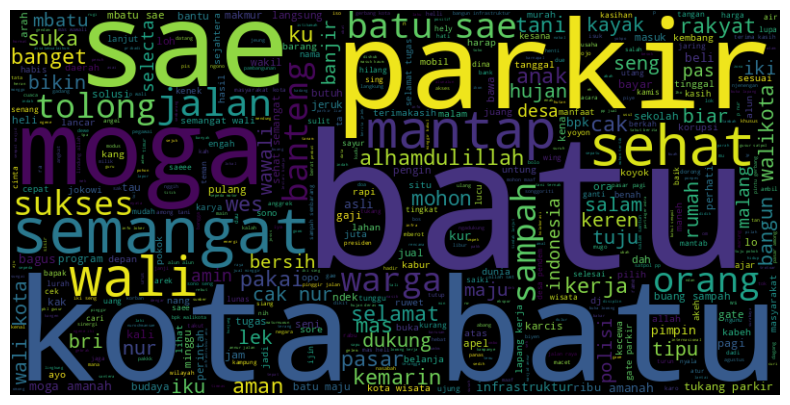

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','yg','nya', 'e', 'aja','sdh','gak','ga', 'di', 'dan', 'pak'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
print(df["steming_data"].head())
print(type(df["steming_data"].iloc[0]))

0                      bangun sinergi kolaborasi depan
1    halo bikin program rumah murah ding warga kota...
2    assalamualaikum wr wb mohon atensi wilayah rw ...
3    riny rizkiriny rizkibagaimana pkl gusur satpol...
4                 anggap pulang cepetcepet uang parkir
Name: steming_data, dtype: object
<class 'str'>


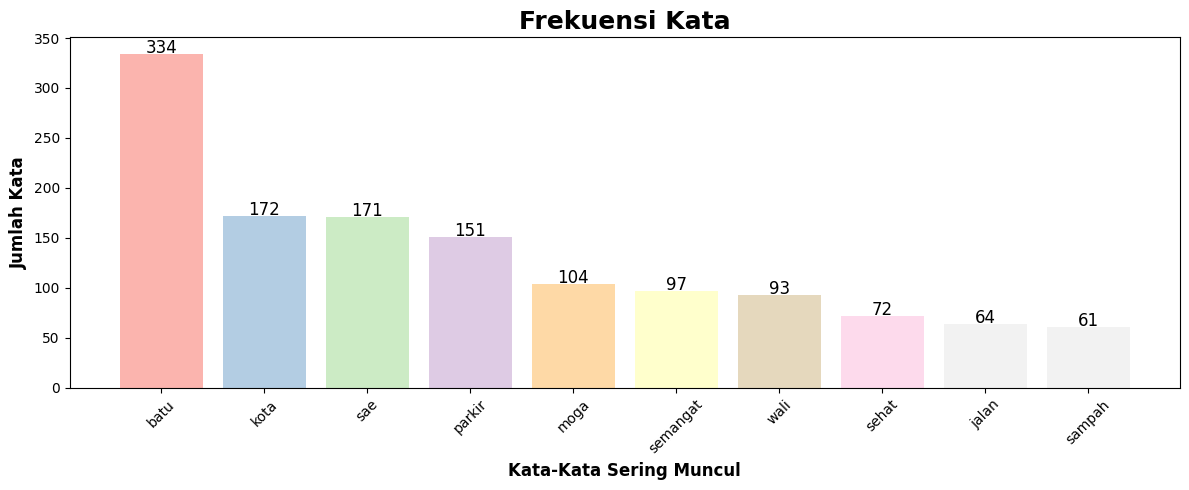

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

all_text = ' '.join(df["steming_data"].astype(str))
all_words = all_text.split()


stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih', 'e', 'yg', 'nya', 'aja', 'sdh', 'gak', 'ga'])

filtered_words = [word for word in all_words if word.lower() not in stopwords]
word_counts = Counter(filtered_words)
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

colors = plt.cm.Pastel1(range(len(word)))

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Tampilkan jumlah di atas bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_data_scraping_tiktok_pemerintahan kota batu.csv',encoding='utf8', index=False);

# ***B. PELEBALAN DATA (LABELING) - LAXICON BASED***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_data_scraping_tiktok_pemerintahan kota batu.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              1460 non-null   object
 1   time              1460 non-null   object
 2   username          1460 non-null   object
 3   diggCount         1460 non-null   int64 
 4   text              1460 non-null   object
 5   cleaning          1430 non-null   object
 6   case_folding      1430 non-null   object
 7   normalisasi       1429 non-null   object
 8   tokenize          1460 non-null   object
 9   stopword removal  1460 non-null   object
 10  steming_data      1421 non-null   object
 11  clean_text        1429 non-null   object
dtypes: int64(1), object(11)
memory usage: 137.0+ KB


,date,time,username,diggCount,text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data,clean_text
0,2025-06-03,20:38:00,oktevabusokte,0,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,membangun sinergi dan kolaborasi ke depannya,"['membangun', 'sinergi', 'dan', 'kolaborasi', ...","['membangun', 'sinergi', 'kolaborasi', 'depann...",bangun sinergi kolaborasi depan,membangun sinergi dan kolaborasi ke depannya
1,2025-04-30,23:01:00,njajanoofficial,0,"Hallo pak, bikin program rumah murah ding, bua...",Hallo pak bikin program rumah murah ding buat ...,hallo pak bikin program rumah murah ding buat ...,halo pak bikin program rumah murah ding buat w...,"['halo', 'pak', 'bikin', 'program', 'rumah', '...","['halo', 'bikin', 'program', 'rumah', 'murah',...",halo bikin program rumah murah ding warga kota...,hallo pak bikin program rumah murah ding buat ...
2,2025-04-29,10:56:00,mas_yusuf94,1,"assalamualaikum wr WB pak, mohon atensinya unt...",assalamualaikum wr WB pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,assalamualaikum wr wb pak mohon atensinya untu...,"['assalamualaikum', 'wr', 'wb', 'pak', 'mohon'...","['assalamualaikum', 'wr', 'wb', 'mohon', 'aten...",assalamualaikum wr wb mohon atensi wilayah rw ...,assalamualaikum wr wb pak mohon atensinya untu...
3,2025-05-09,09:32:00,rinyrizki30,0,@Riny rizki:@Riny rizki:bagaimana dengan pkl y...,Riny rizkiRiny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,riny rizkiriny rizkibagaimana dengan pkl yang ...,"['riny', 'rizkiriny', 'rizkibagaimana', 'denga...","['riny', 'rizkiriny', 'rizkibagaimana', 'pkl',...",riny rizkiriny rizkibagaimana pkl gusur satpol...,riny rizkiriny rizkibagaimana dengan pkl yang ...
4,2025-07-16,00:40:00,.hnaudio,167,datang tidak dianggap kalo mau pulang cepet-ce...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalo mau pulang cepetcep...,datang tidak dianggap kalau mau pulang cepetce...,"['datang', 'tidak', 'dianggap', 'kalau', 'mau'...","['dianggap', 'pulang', 'cepetcepet', 'uang', '...",anggap pulang cepetcepet uang parkir,datang tidak dianggap kalo mau pulang cepetcep...


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1421 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              1421 non-null   object
 1   time              1421 non-null   object
 2   username          1421 non-null   object
 3   diggCount         1421 non-null   int64 
 4   text              1421 non-null   object
 5   cleaning          1421 non-null   object
 6   case_folding      1421 non-null   object
 7   normalisasi       1421 non-null   object
 8   tokenize          1421 non-null   object
 9   stopword removal  1421 non-null   object
 10  steming_data      1421 non-null   object
 11  clean_text        1421 non-null   object
dtypes: int64(1), object(11)
memory usage: 144.3+ KB


In [ ]:
data = pd.DataFrame(data[['date','time','username','diggCount','steming_data']])
data.head(5)

,date,time,username,diggCount,steming_data
0,2025-06-03,20:38:00,oktevabusokte,0,bangun sinergi kolaborasi depan
1,2025-04-30,23:01:00,njajanoofficial,0,halo bikin program rumah murah ding warga kota...
2,2025-04-29,10:56:00,mas_yusuf94,1,assalamualaikum wr wb mohon atensi wilayah rw ...
3,2025-05-09,09:32:00,rinyrizki30,0,riny rizkiriny rizkibagaimana pkl gusur satpol...
4,2025-07-16,00:40:00,.hnaudio,167,anggap pulang cepetcepet uang parkir


### **1. Proses Labeling Data (Positif / Negatif / Netral)**

In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['steming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(5)


,date,time,username,diggCount,steming_data,Score,Sentiment
0,2025-06-03,20:38:00,oktevabusokte,0,bangun sinergi kolaborasi depan,0,Netral
1,2025-04-30,23:01:00,njajanoofficial,0,halo bikin program rumah murah ding warga kota...,3,Positif
2,2025-04-29,10:56:00,mas_yusuf94,1,assalamualaikum wr wb mohon atensi wilayah rw ...,1,Positif
3,2025-05-09,09:32:00,rinyrizki30,0,riny rizkiriny rizkibagaimana pkl gusur satpol...,3,Positif
4,2025-07-16,00:40:00,.hnaudio,167,anggap pulang cepetcepet uang parkir,1,Positif


/tmp/ipython-input-43-1910355637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


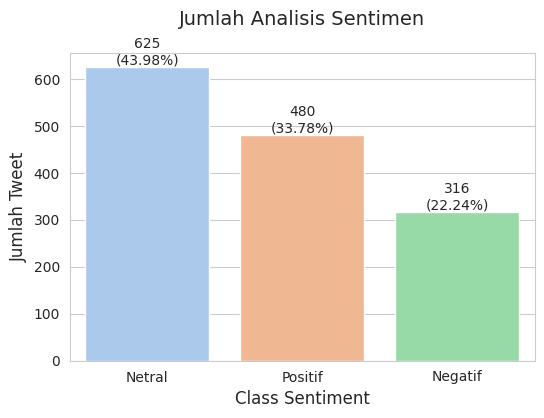

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling__data_scraping_tiktok_pemerintahan kota batu.csv',encoding='utf8', index=False)

### **2. WordCloud Semua Label**

---



In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling__data_scraping_tiktok_pemerintahan kota batu.csv")
data.head(5)

,date,time,username,diggCount,steming_data,Score,Sentiment
0,2025-06-03,20:38:00,oktevabusokte,0,bangun sinergi kolaborasi depan,0,Netral
1,2025-04-30,23:01:00,njajanoofficial,0,halo bikin program rumah murah ding warga kota...,3,Positif
2,2025-04-29,10:56:00,mas_yusuf94,1,assalamualaikum wr wb mohon atensi wilayah rw ...,1,Positif
3,2025-05-09,09:32:00,rinyrizki30,0,riny rizkiriny rizkibagaimana pkl gusur satpol...,3,Positif
4,2025-07-16,00:40:00,.hnaudio,167,anggap pulang cepetcepet uang parkir,1,Positif


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

### **3. WordCloud Sentimen Negatif**

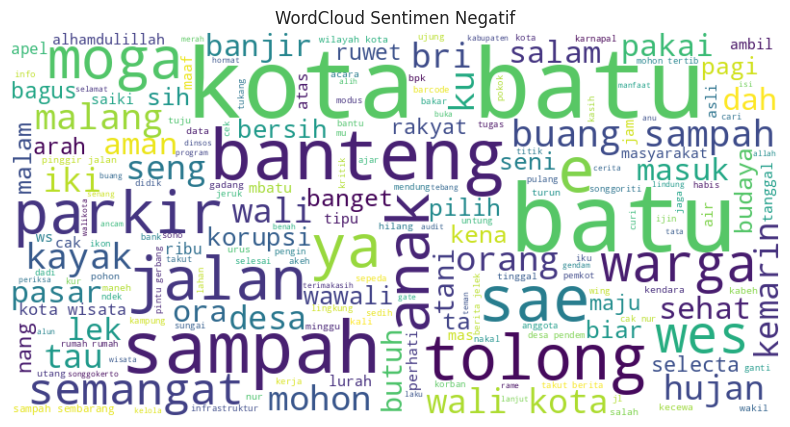

In [ ]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

### **4. WordCloud Sentimen Positif**

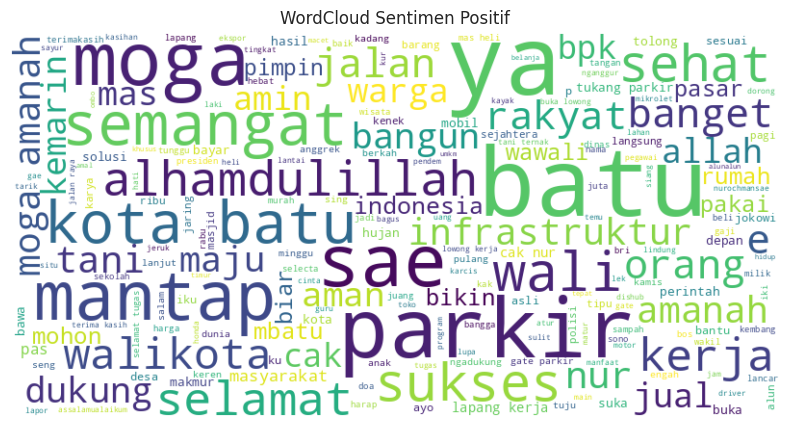

In [ ]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

### **5. WordCloud Sentimen Netral**

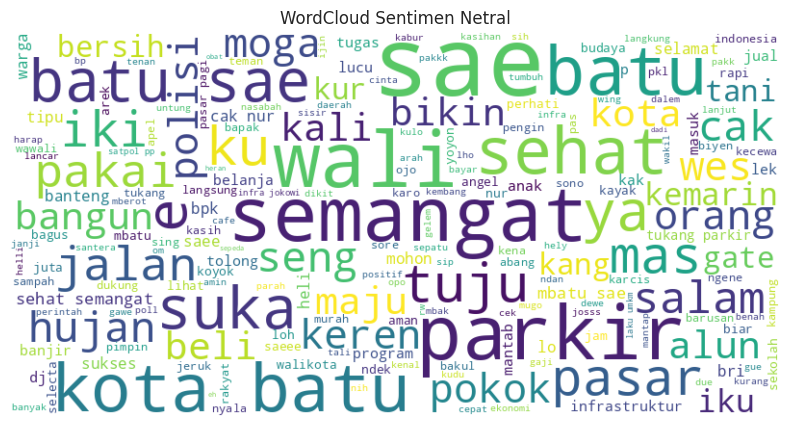

In [ ]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

# ***C. SPLITING DATA***

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling__data_scraping_tiktok_pemerintahan kota batu.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1421 non-null   object
 1   time          1421 non-null   object
 2   username      1421 non-null   object
 3   diggCount     1421 non-null   int64 
 4   steming_data  1421 non-null   object
 5   Score         1421 non-null   int64 
 6   Sentiment     1421 non-null   object
dtypes: int64(2), object(5)
memory usage: 77.8+ KB


,date,time,username,diggCount,steming_data,Score,Sentiment
0,2025-06-03,20:38:00,oktevabusokte,0,bangun sinergi kolaborasi depan,0,Netral
1,2025-04-30,23:01:00,njajanoofficial,0,halo bikin program rumah murah ding warga kota...,3,Positif
2,2025-04-29,10:56:00,mas_yusuf94,1,assalamualaikum wr wb mohon atensi wilayah rw ...,1,Positif
3,2025-05-09,09:32:00,rinyrizki30,0,riny rizkiriny rizkibagaimana pkl gusur satpol...,3,Positif
4,2025-07-16,00:40:00,.hnaudio,167,anggap pulang cepetcepet uang parkir,1,Positif


### **1. Train dan Test Split (80:20)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = data.dropna(subset=['steming_data'])

X = cleaned_data['steming_data']
y = cleaned_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

Jumlah data latih: 1136
Jumlah data uji: 285


((1136, 2523), (285, 2523))

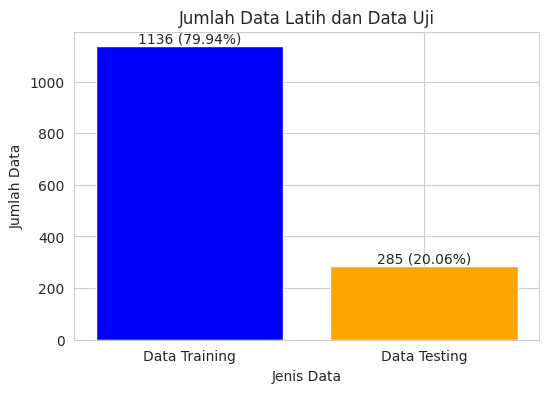

In [ ]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()


# ***D. Evaluasi Model SVM (Support Vector Machine), KNN (K-Nearest Neighbor), Naive Bayes, Random Forest, Decision Tree, Neural Network***

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Initialize models
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
}

# Train models
results = {}
for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

### **1. Confusion Matrix**


Confusion Matrix for SVM:


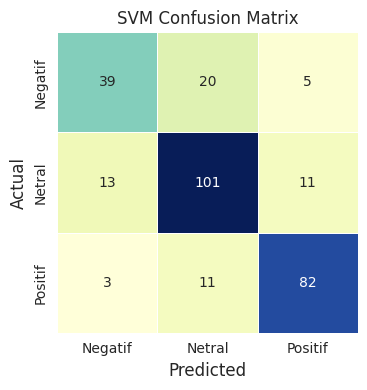


Confusion Matrix for KNN:


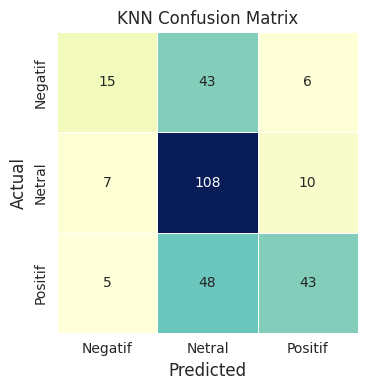


Confusion Matrix for Naive Bayes:


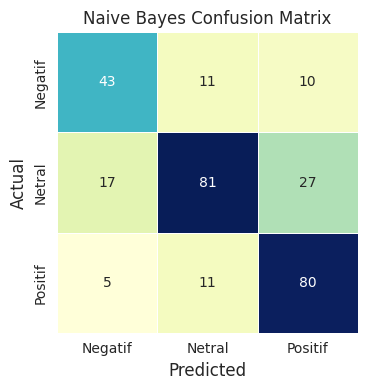


Confusion Matrix for Random Forest:


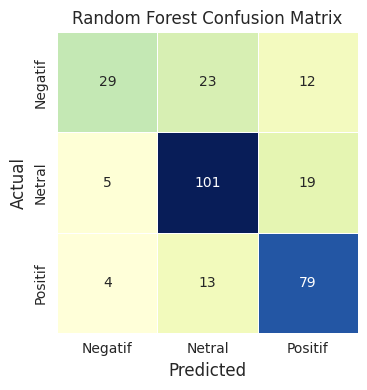


Confusion Matrix for Decision Trees:


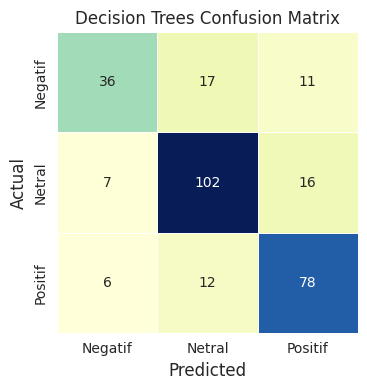


Confusion Matrix for Neural Network:


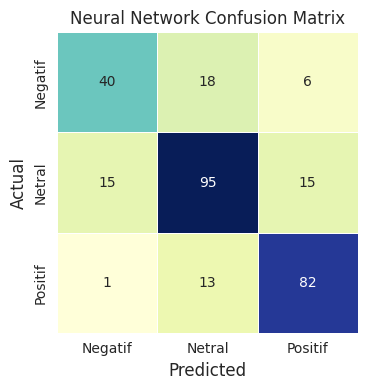

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif', 'Netral', 'Positif'],
        yticklabels=['Negatif', 'Netral', 'Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


### **2. Model Accuracy Comparison**

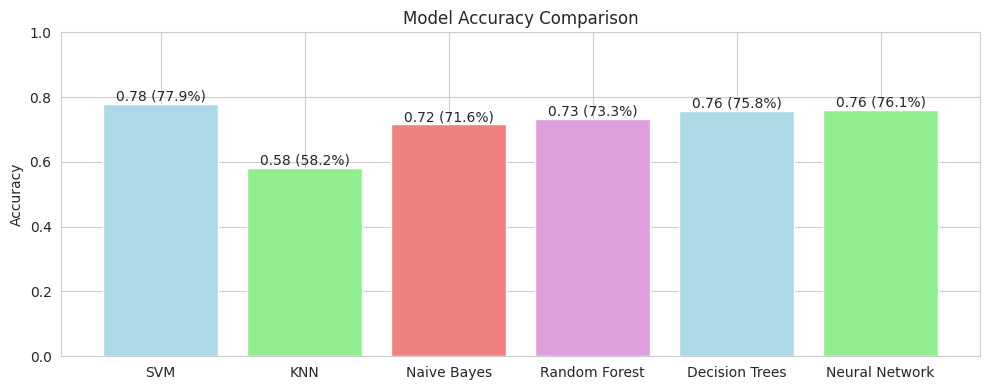

In [ ]:
import matplotlib.pyplot as plt

accuracies = {model: result['accuracy'] for model, result in results.items()}

plt.figure(figsize=(10, 4))
bars = plt.bar(list(accuracies.keys()), list(accuracies.values()), color=['lightblue', 'lightgreen', 'lightcoral', 'plum'])

for bar in bars:
    accuracy = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### **3. Classification Report**

In [ ]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.709,0.609,0.655,64.000
Netral,0.765,0.808,0.786,125.000
Positif,0.837,0.854,0.845,96.000
accuracy,0.779,0.779,0.779,0.779
macro avg,0.770,0.757,0.762,285.000
weighted avg,0.777,0.779,0.777,285.000



Classification Report for KNN:


,precision,recall,f1-score,support
Negatif,0.556,0.234,0.330,64.000
Netral,0.543,0.864,0.667,125.000
Positif,0.729,0.448,0.555,96.000
accuracy,0.582,0.582,0.582,0.582
macro avg,0.609,0.515,0.517,285.000
weighted avg,0.608,0.582,0.553,285.000



Classification Report for Naive Bayes:


...

,precision,recall,f1-score,support
Negatif,0.763,0.453,0.569,64.000
Netral,0.737,0.808,0.771,125.000
Positif,0.718,0.823,0.767,96.000
accuracy,0.733,0.733,0.733,0.733
macro avg,0.740,0.695,0.702,285.000
weighted avg,0.737,0.733,0.724,285.000



Classification Report for Decision Trees:


,precision,recall,f1-score,support
Negatif,0.735,0.562,0.637,64.000
Netral,0.779,0.816,0.797,125.000
Positif,0.743,0.812,0.776,96.000
accuracy,0.758,0.758,0.758,0.758
macro avg,0.752,0.730,0.737,285.000
weighted avg,0.757,0.758,0.754,285.000



Classification Report for Neural Network:


,precision,recall,f1-score,support
Negatif,0.714,0.625,0.667,64.000
Netral,0.754,0.760,0.757,125.000
Positif,0.796,0.854,0.824,96.000
accuracy,0.761,0.761,0.761,0.761
macro avg,0.755,0.746,0.749,285.000
weighted avg,0.759,0.761,0.759,285.000
